<a href="https://colab.research.google.com/github/s32ol/predictive-maintenance-ai4i/blob/main/notebooks/02_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1: EDA Verification

This notebook reproduces and verifies the Phase 1 EDA findings from the project README against live data, then translates each finding into both technical and business-facing language.

Dataset: AI4I 2020 Predictive Maintenance (Matzka, 2020) — 10,000 rows of synthetic CNC milling telemetry with a binary failure label.

Goal: build a classifier that flags machines at risk of failure from sensor readings, while remaining honest about a 28:1 class imbalance.

Structure of each finding below:

- What we measured (the code result)

- Technical interpretation — for data-science reviewers

- Business interpretation — for non-technical stakeholders

- Decisions this drives in Phase 2 — modeling implications

Every modeling choice in Phase 2 traces back to one of these four findings.

In [1]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
df = pd.read_csv(url)
df.shape

(10000, 14)

In [2]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

## Setup & sanity checks

Data loaded directly from the UCI ML Repository (the original source — Kaggle hosts a mirror).

Sanity check results:

- 10,000 rows × 14 columns ✓

- No null values in any column ✓

- Dtypes correct: sensors numeric, Type and Product ID as strings, binary flags as int ✓

- Memory footprint ~1.1 MB

Translation for stakeholders: the data is small, clean, and complete. No data-quality issues at the structural level. Ready for analysis.

In [4]:
print(df['Machine failure'].value_counts())
print()
print(df['Machine failure'].value_counts(normalize=True))

Machine failure
0    9661
1     339
Name: count, dtype: int64

Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64


## Finding 1: Class imbalance — 28:1

### Technical interpretation

The dataset is heavily imbalanced: 9,661 non-failures (96.61%) and 339 failures (3.39%) — a 28.5:1 negative-to-positive ratio. This rules out accuracy as a meaningful metric; a trivial model that predicts "no failure" for every row would score 96.6% accurate and have zero business value. Imbalance also drives the choice of split strategy (stratified), evaluation metric (PR-AUC over ROC-AUC), and training procedure (class weighting).

### Business interpretation

Roughly 1 in 30 machines fails. This is a needle-in-haystack detection problem, not a balanced classification problem. A model that says "everything's fine" all the time would be technically right 97% of the time — but never catch a failure, which defeats the purpose.

### Decisions this drives in Phase 2

- Stratified splits — every train/test/CV fold preserves the 3.4% failure rate so each fold has enough positives to learn from

- PR-AUC as the primary metric — not accuracy, not even ROC-AUC (which inflates with imbalance because the negative class dominates the FPR denominator)

- Class weighting during training — class_weight='balanced' for logistic regression, scale_pos_weight=~28 for XGBoost

- Threshold tuning — the default 0.5 is too strict for rare classes; we tune toward higher recall, since missed failures cost ~10× more than false alarms in a maintenance context

In [5]:
sensor_cols = ['Air temperature [K]', 'Process temperature [K]',
               'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

df[sensor_cols].corr().round(2)

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Air temperature [K],1.00,0.88,0.02,-0.01,0.01
Process temperature [K],0.88,1.00,0.02,-0.01,0.01
Rotational speed [rpm],0.02,0.02,1.00,-0.88,0.00
Torque [Nm],-0.01,-0.01,-0.88,1.00,-0.00
Tool wear [min],0.01,0.01,0.00,-0.00,1.00


### Visualizing the correlation matrix

Same numerical data as the table above, rendered as a heatmap so the strong correlations jump out at a glance.

**What to look for:**
- Two **deeply colored off-diagonal cells** — one positive (red), one negative (blue) — at the (Air temp, Process temp) and (Rotational speed, Torque) positions. These are the +0.88 and −0.88 correlations.
- The **diagonal is all 1.00** by construction (every variable correlates perfectly with itself) — ignore it.
- **Everything else is near-white**, confirming those sensor pairs are essentially uncorrelated. Tool wear's row and column are near-zero across the board, which means it's independent of every other sensor — useful unique signal.

The physics explanation and feature engineering decisions that flow from these correlations are in **Finding 2** below.

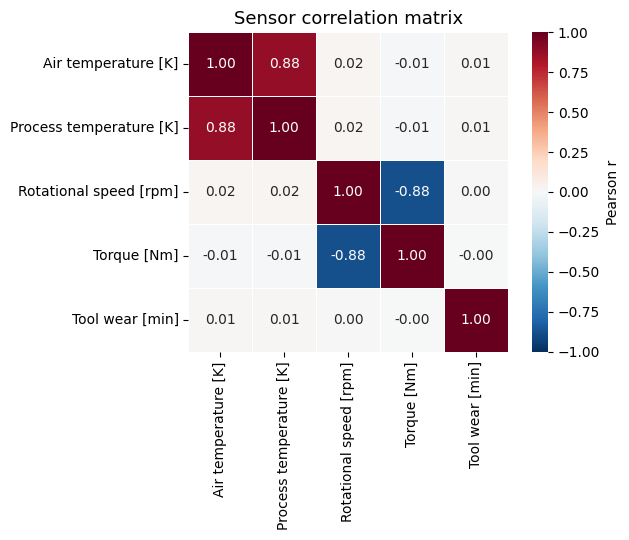

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[sensor_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set_title('Sensor correlation matrix', fontsize=13)
plt.tight_layout()
plt.show()

## Finding 2: Multicollinearity — physics-driven correlations

### Technical interpretation

Two strong correlations among the five sensor channels:

- Air temperature ↔ Process temperature: +0.88 — process temperature is constructed additively from air temperature (per dataset spec: process_temp ≈ air_temp + 10K + noise).

- Rotational speed ↔ Torque: −0.88 — at the machine's roughly constant ~2,860 W operating power, torque and rpm trade off mechanically (Power = Torque × ω).

All other correlations are essentially zero. Tool wear is independent of every other sensor, which means it carries unique information not captured anywhere else — it accumulates monotonically with time, regardless of operating conditions.

### Business interpretation

Two pairs of sensors are mechanically linked:

- Room temp and cutting temp move together — when the workshop gets hot, the cutting gets hot.

- Spindle speed and torque are inversely linked — same as a vehicle transmission. Low gear = high torque + low speed; high gear = low torque + high speed.

Tool wear is its own story — it accumulates over time regardless of operating conditions, so it carries unique signal.

### Decisions this drives in Phase 2

We don't drop a feature from each correlated pair (that loses information). Instead, we engineer the underlying physical quantities directly:

- **temp_diff** = `process_temp − air_temp` — isolates heat generated by the cutting operation, separated from ambient. This is the variable that should drive heat dissipation failures (per the dataset spec, HDF triggers when this gap drops below 8.6 K).

- **power_proxy** = `torque × rotational_speed` — the actual power being drawn. Per the dataset spec, power failures (PWF) trigger below 3,500 W or above 9,000 W.

These engineered features are derived from physics, not statistics — they map directly to the documented failure-mode triggers.

In [6]:
df.groupby('Type')['Machine failure'].mean()

,Machine failure
Type,
H,0.020937
L,0.039167
M,0.027694


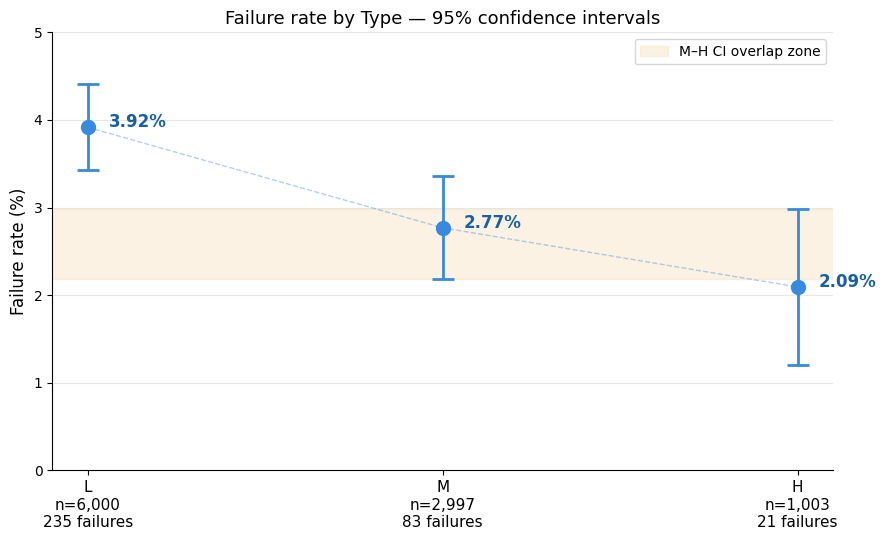

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Compute rates, sample sizes, and failure counts
stats = df.groupby('Type')['Machine failure'].agg(['mean', 'count', 'sum'])
stats = stats.reindex(['L', 'M', 'H'])  # enforce L → M → H order

p = stats['mean'].values
n = stats['count'].values
failures = stats['sum'].values
ci_95 = 1.96 * np.sqrt(p * (1 - p) / n)  # 95% CI half-width

# Build the chart
fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(3)
types = ['L', 'M', 'H']

# Points with error bars
ax.errorbar(x, p * 100, yerr=ci_95 * 100, fmt='o',
            color='#378ADD', ecolor='#378ADD',
            capsize=8, capthick=2, markersize=10, linewidth=2)

# Dashed trend line
ax.plot(x, p * 100, '--', color='#378ADD', alpha=0.4, linewidth=1)

# Rate labels next to each point
for i in range(3):
    ax.annotate(f'{p[i]*100:.2f}%', (x[i], p[i] * 100),
                xytext=(15, 0), textcoords='offset points',
                fontsize=12, color='#185FA5', fontweight='bold')

# M-H CI overlap zone (the noisy region)
m_low, m_high = (p[1] - ci_95[1]) * 100, (p[1] + ci_95[1]) * 100
h_low, h_high = (p[2] - ci_95[2]) * 100, (p[2] + ci_95[2]) * 100
overlap_low = max(m_low, h_low)
overlap_high = min(m_high, h_high)
if overlap_high > overlap_low:
    ax.axhspan(overlap_low, overlap_high, alpha=0.13, color='#EF9F27',
               label='M–H CI overlap zone')

ax.set_xticks(x)
ax.set_xticklabels([f"{t}\nn={n[i]:,}\n{failures[i]} failures"
                    for i, t in enumerate(types)], fontsize=11)
ax.set_ylabel('Failure rate (%)', fontsize=12)
ax.set_title('Failure rate by Type — 95% confidence intervals', fontsize=13)
ax.set_ylim(0, 5)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(loc='upper right', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Finding 3: Failure rate by Type — monotonic, with noisy edges

### Technical interpretation

Failure rate by product Type forms a monotonic descent:

| Type | n | Failures | Rate | 95% CI |
|------|---|----------|------|--------|
| L | 6,000 | 235 | 3.92% | [3.4%, 4.4%] |
| M | 3,000 | 83 | 2.77% | [2.2%, 3.4%] |
| H | 1,000 | 21 | 2.09% | [1.2%, 3.0%] |

Statistical reading:

- The L-vs-rest gap is robust (CIs don't overlap with M or H).

- The M-vs-H gap is borderline — CIs overlap from 2.2% to 3.0%, so they could plausibly share the same true rate.

- The monotonic trend itself is evidence of an ordered underlying cause — three points in the right order, consistent with the physics, is harder to explain by chance than any single pairwise comparison being significant.

Doc-vs-data discrepancy: the actual Type distribution is L 60% / M 30% / H 10%, not the 50/30/20 the dataset description claims. The data is the ground truth.

### Business interpretation

Lower-grade parts fail meaningfully more often than higher-grade parts. About 4% of L-grade machining jobs fail, vs about 2% for H-grade. M (medium) sits between them. This makes physical sense — cheaper, more variable raw stock stresses the cutting tool more, leading to more failures.

We have strong evidence for the L-vs-rest gap. The middle (M vs H) is fuzzier because we only have ~21 H-grade failures in the entire dataset, so the H rate has wide statistical uncertainty.

### Decisions this drives in Phase 2

- Keep Type as a feature — it carries real signal

- One-hot encode it (L/M/H → binary indicator columns)

- Stratify splits on Type — with only 21 H-grade failures, we can't afford to lose them all to one fold

In [8]:
# Check: does Machine failure equal the OR of the 5 mode flags, row by row?
mode_or = df[['TWF', 'HDF', 'PWF', 'OSF', 'RNF']].any(axis=1).astype(int)

exact_match = (mode_or == df['Machine failure']).all()
print(f"Perfect match across all 10,000 rows? {exact_match}")

if not exact_match:
    mismatches = df[mode_or != df['Machine failure']]
    print(f"\nMismatching rows: {len(mismatches)} out of {len(df)} "
          f"({len(mismatches)/len(df)*100:.3f}%)")
    print("\nThe mismatches:")
    print(mismatches[['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']])

Perfect match across all 10,000 rows? False

Mismatching rows: 27 out of 10000 (0.270%)

The mismatches:
      Machine failure  TWF  HDF  PWF  OSF  RNF
1221                0    0    0    0    0    1
1302                0    0    0    0    0    1
1437                1    0    0    0    0    0
1748                0    0    0    0    0    1
2072                0    0    0    0    0    1
2559                0    0    0    0    0    1
2749                1    0    0    0    0    0
3065                0    0    0    0    0    1
3452                0    0    0    0    0    1
4044                1    0    0    0    0    0
4684                1    0    0    0    0    0
5471                0    0    0    0    0    1
5489                0    0    0    0    0    1
5495                0    0    0    0    0    1
5509                0    0    0    0    0    1
5536                1    0    0    0    0    0
5553                0    0    0    0    0    1
5639                0    0    0    0    0    1
59

## Finding 4: Target leakage — TWF / HDF / PWF / OSF / RNF must be dropped

### Technical interpretation

The five "failure mode" columns are not features but components of the target label. Per the dataset spec, the relationship is:

```
Machine failure = TWF OR HDF OR PWF OR OSF OR RNF
```

Verification on the actual data: the relationship holds for 99.73% of rows (9,973 / 10,000) with 27 anomalies in two distinct patterns:

- 18 rows where RNF=1 but Machine failure=0 (random-failure flag didn't propagate to the label)

- 9 rows where Machine failure=1 but all five mode flags=0 (failure with no labeled cause)

Negligible noise at 0.27%, but a real doc-vs-data discrepancy worth surfacing.

These five columns are textbook target leakage — they're computed from the failure event, not before it. Training with them would produce a model scoring ~99.7% on validation (because it's reading off the answer key) and useless in production (because at inference time, the failure hasn't happened yet, so these columns don't exist).

### Business interpretation

The five failure-type columns aren't sensor readings — they're labels describing which kind of failure happened. They only exist after a failure occurs. If we trained the model with them, we'd be handing it the answer. The model would look brilliant in testing and crash the moment we deployed it.

Analogy: predicting whether a bearing will fail using the post-failure inspection report as a feature. The inspection report is gold — but it only exists after the bearing has failed. Useless for prediction.

### Decisions this drives in Phase 2

- Drop TWF, HDF, PWF, OSF, RNF before any modeling code runs — non-negotiable

- Also drop UDI (unique row identifier, no predictive value) and Product ID (high-cardinality string that would bloat the feature space without adding signal beyond what Type already captures)

## Phase 1 summary — the decision spine for Phase 2

Every modeling choice in Phase 2 flows from one of these four findings:

| Finding | Decisions it drives |
|---------|---------------------|
| 28:1 class imbalance | Stratified splits, PR-AUC as primary metric, class weighting, threshold tuning |
| Multicollinearity (physics) | Engineer temp_diff and power_proxy instead of dropping features |
| Type carries signal | Keep Type, one-hot encode, stratify on it |
| Target leakage | Drop TWF/HDF/PWF/OSF/RNF (plus UDI, Product ID) |

Bonus findings surfaced during verification:

- Type distribution doesn't match docs — actual is 60/30/10, documented as 50/30/20

- Tool wear is independent of every other sensor — carries unique signal worth keeping

- Two distinct patterns of label noise in the leakage relationship (18 RNF-orphans + 9 unexplained failures)

Methodological note: every finding above was reproduced from raw data in this notebook, not just summarized from the README. The act of verifying — rather than trusting documentation — surfaced two doc-vs-data discrepancies that the original spec doesn't mention.

Next: Phase 2 — feature engineering and stratified split.